In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# Configuration
DATASET_PATH = r"C:\Users\dell\ECG - Cardialyse Final Year Project\ECG_Dataset_Original" 
IMG_SIZE = (224, 224)
BATCH_SIZE = 16 
NUM_CLASSES = 4
EPOCHS = 15      

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow Version: 2.19.0
Num GPUs Available: 0


In [4]:
import glob

class_names = sorted(os.listdir(DATASET_PATH))
print("Detected Classes:", class_names)


Detected Classes: ['ECG Images of Myocardial Infarction Patients (240x12=2880)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'Normal Person ECG Images (284x12=3408)']


In [5]:
label_map = {class_name: idx for idx, class_name in enumerate(class_names)}
print("Label Mapping:", label_map)

# Collect image paths and labels
image_paths = []
labels = []

for class_name in class_names:
    class_folder = os.path.join(DATASET_PATH, class_name)
    images = glob.glob(os.path.join(class_folder, "**", "*.jpg"), recursive=True)

    
    for img_path in images:
        image_paths.append(img_path)
        labels.append(label_map[class_name])

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total Images:", len(image_paths))


Label Mapping: {'ECG Images of Myocardial Infarction Patients (240x12=2880)': 0, 'ECG Images of Patient that have History of MI (172x12=2064)': 1, 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)': 2, 'Normal Person ECG Images (284x12=3408)': 3}
Total Images: 928


In [6]:

# Stratified Split

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

In [7]:
# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 649
Validation size: 139
Test size: 140


In [8]:
# Check class distribution
def print_distribution(y, name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n{name} Distribution:")
    for u, c in zip(unique, counts):
        print(f"{class_names[u]}: {c}")

print_distribution(y_train, "Train")
print_distribution(y_val, "Validation")
print_distribution(y_test, "Test")


Train Distribution:
ECG Images of Myocardial Infarction Patients (240x12=2880): 167
ECG Images of Patient that have History of MI (172x12=2064): 120
ECG Images of Patient that have abnormal heartbeat (233x12=2796): 163
Normal Person ECG Images (284x12=3408): 199

Validation Distribution:
ECG Images of Myocardial Infarction Patients (240x12=2880): 36
ECG Images of Patient that have History of MI (172x12=2064): 26
ECG Images of Patient that have abnormal heartbeat (233x12=2796): 35
Normal Person ECG Images (284x12=3408): 42

Test Distribution:
ECG Images of Myocardial Infarction Patients (240x12=2880): 36
ECG Images of Patient that have History of MI (172x12=2064): 26
ECG Images of Patient that have abnormal heartbeat (233x12=2796): 35
Normal Person ECG Images (284x12=3408): 43


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

# Image Loading Function

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

In [10]:
# Data Augmentation (Safe for ECG)

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.02),   # small rotation (~3°)
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.1),
])

In [11]:
# Build Datasets
def build_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x), y),
                    num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(500)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = build_dataset(X_train, y_train, training=True)
val_ds   = build_dataset(X_val, y_val, training=False)
test_ds  = build_dataset(X_test, y_test, training=False)

print("Datasets prepared successfully.")


Datasets prepared successfully.


In [12]:
# MODEL BUILDING
# Load pretrained ResNet50
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 98s 1us/step


In [13]:
# Freeze backbone
base_model.trainable = False

# Build model
inputs = keras.Input(shape=(224, 224, 3))

In [14]:
# ResNet preprocessing
x = tf.keras.applications.resnet.preprocess_input(inputs)

# Pass through base model
x = base_model(x, training=False)

# Global pooling
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.Dropout(0.5)(x)


In [15]:
# Output layer
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# Model summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 224, 224)          │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 224, 224)          │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 224, 224)          │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack (Stack)                 │ (None, 224, 224, 3)       │               0 │ get_item[0][0],            │
│                               │                           │                 │ get_item_1[0][0],          │
│                               │                           │                 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 224, 224, 3)       │               0 │ stack[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resnet50 (Functional)         │ (None, 7, 7, 2048)        │      23,587,712 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d      │ (None, 2048)              │               0 │ resnet50[0][0]             │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 2048)              │               0 │ global_average_pooling2d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 4)                 │           8,196 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [16]:
# BLOCK 5: COMPILE + CALLBACKS

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "best_ecg_model.keras",
    monitor="val_loss",
    save_best_only=True
)

print("Model compiled and callbacks ready.")

Model compiled and callbacks ready.


In [18]:
# TRAINING
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.2613 - loss: 1.7934 - val_accuracy: 0.3741 - val_loss: 1.4042 - learning_rate: 0.0010
Epoch 2/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.3829 - loss: 1.3886 - val_accuracy: 0.3885 - val_loss: 1.2552 - learning_rate: 0.0010
Epoch 3/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.4101 - loss: 1.3073 - val_accuracy: 0.3453 - val_loss: 1.3552 - learning_rate: 0.0010
Epoch 4/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.4597 - loss: 1.2399 - val_accuracy: 0.3669 - val_loss: 1.3119 - learning_rate: 0.0010
Epoch 5/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.4559 - loss: 1.1403 - val_accuracy: 0.4173 - val_loss: 1.2049 - learning_rate: 0.0010
Epoch 6/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.5272 - loss: 1.0961 - val_accuracy: 0.4460 - val_loss: 1.1414 - learning_rate: 0.0010
Epoch 7/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.5038 - loss: 1.0955 - val_accuracy: 

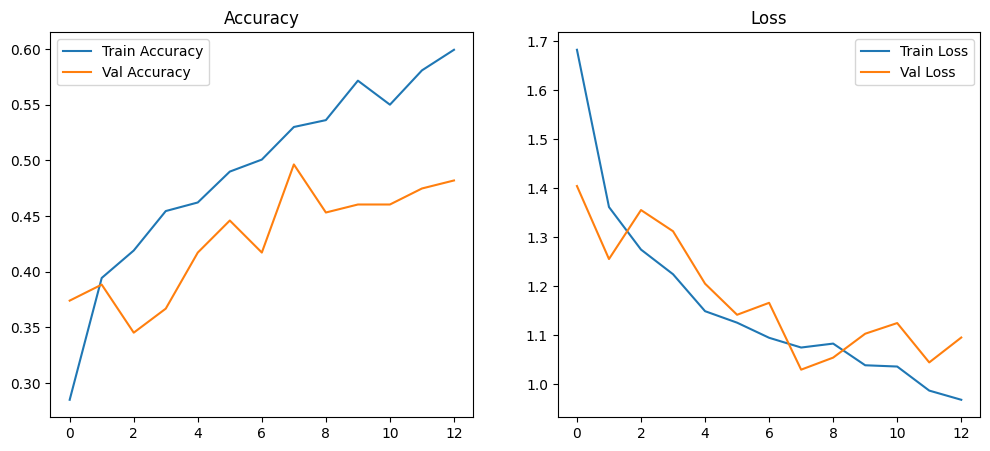

In [19]:
# Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()


In [20]:
#TEST EVALUATION

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6208 - loss: 0.9705

Test Accuracy: 0.6429
Test Loss: 0.9195


In [21]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)


9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step


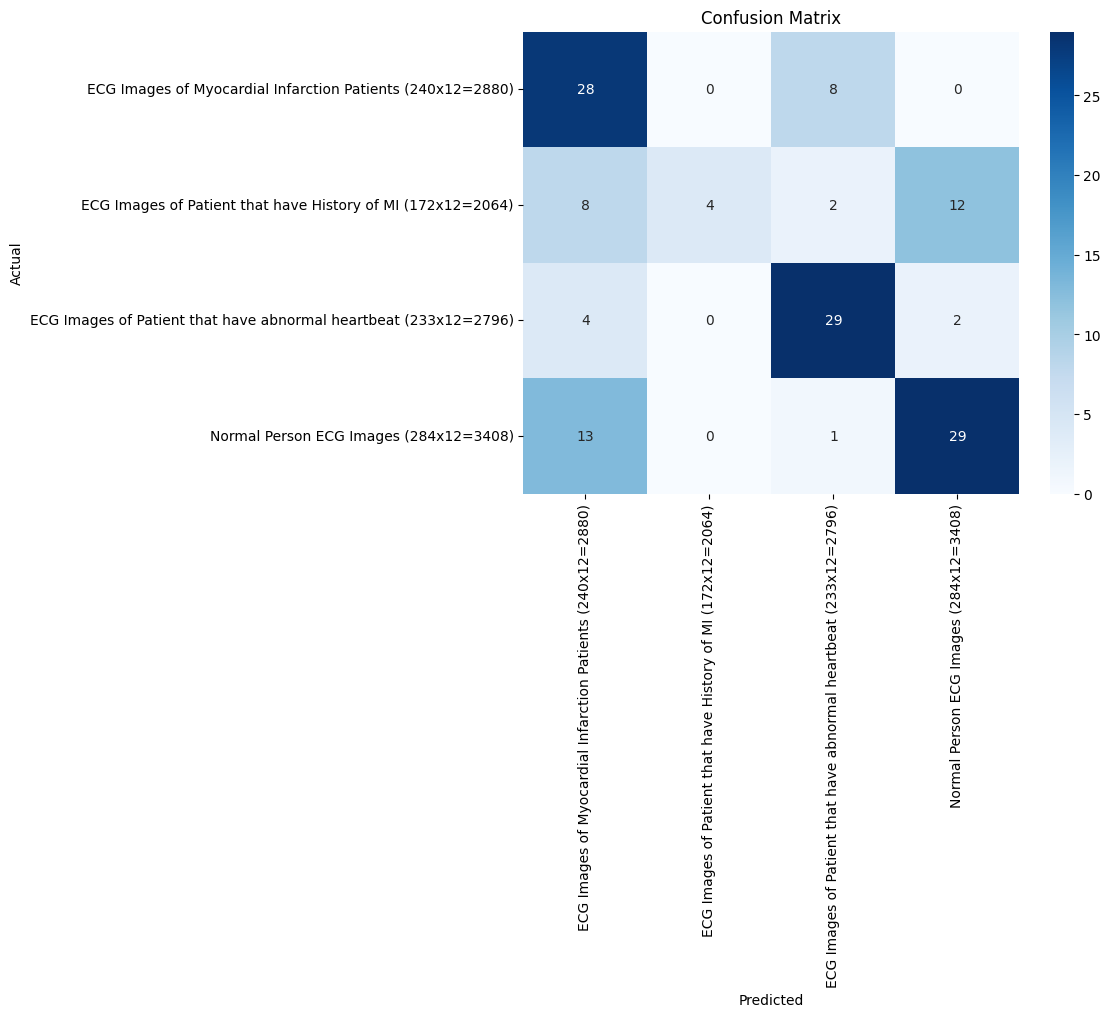

In [22]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.53      0.78      0.63        36
     ECG Images of Patient that have History of MI (172x12=2064)       1.00      0.15      0.27        26
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       0.72      0.83      0.77        35
                          Normal Person ECG Images (284x12=3408)       0.67      0.67      0.67        43

                                                        accuracy                           0.64       140
                                                       macro avg       0.73      0.61      0.59       140
                                                    weighted avg       0.71      0.64      0.61       140



In [24]:
# BLOCK 8: FINE-TUNING

# Unfreeze last layers
base_model.trainable = True

# Freeze first 140 layers (keep early layers fixed)
for layer in base_model.layers[:140]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model...")

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Fine-tuning model...
Epoch 1/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.4411 - loss: 1.6533 - val_accuracy: 0.5468 - val_loss: 1.0057 - learning_rate: 1.0000e-05
Epoch 2/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.5146 - loss: 1.2537 - val_accuracy: 0.5540 - val_loss: 1.0334 - learning_rate: 1.0000e-05
Epoch 3/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.5496 - loss: 1.0996 - val_accuracy: 0.4820 - val_loss: 1.3143 - learning_rate: 1.0000e-05
Epoch 4/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.5880 - loss: 1.0139 - val_accuracy: 0.4748 - val_loss: 1.5797 - learning_rate: 1.0000e-05
Epoch 5/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.6287 - loss: 0.8992 - val_accuracy: 0.4604 - val_loss: 1.7473 - learning_rate: 3.0000e-06
Epoch 6/8
41/41 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.6253 - loss: 0.9106 - val_accuracy: 0.4676 - val_loss: 1.6323 - learning_rate: 3.0000e-06


9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5533 - loss: 0.9862

Test Accuracy: 0.6000
Test Loss: 0.9133
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step


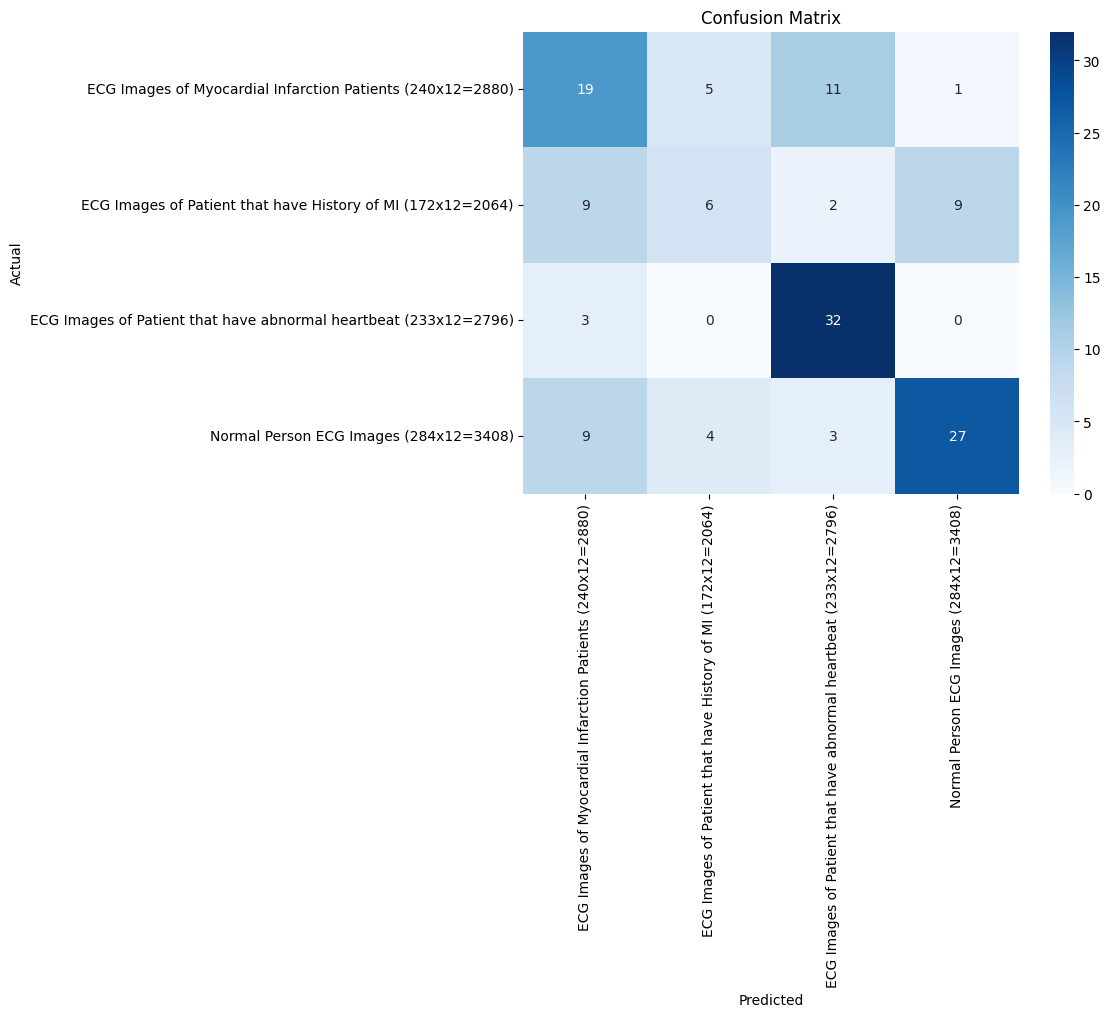


Classification Report:

                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.47      0.53      0.50        36
     ECG Images of Patient that have History of MI (172x12=2064)       0.40      0.23      0.29        26
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       0.67      0.91      0.77        35
                          Normal Person ECG Images (284x12=3408)       0.73      0.63      0.68        43

                                                        accuracy                           0.60       140
                                                       macro avg       0.57      0.58      0.56       140
                                                    weighted avg       0.59      0.60      0.58       140



In [25]:
# ==========================
# BLOCK 7: TEST EVALUATION
# ==========================

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


# Get predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)


# --------------------------
# Confusion Matrix
# --------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# --------------------------
# Classification Report
# --------------------------
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


In [27]:
model = keras.models.load_model("best_ecg_model.keras")

In [28]:
model = tf.keras.models.load_model("best_ecg_model.keras")

print("Best model loaded successfully.")


Best model loaded successfully.


In [29]:
model.save("ecg_resnet50_v1_64percent.keras")


In [31]:
import json

class_info = {
    "class_names": class_names,
    "label_map": label_map
}

with open("class_mapping.json", "w") as f:
    json.dump(class_info, f)
